# Separate elementary/middle and EOC income regressions

This notebook analyzes the relationship between district median household income and Spring 2026 STAAR performance separately for:

1. **Elementary/middle STAAR results**
2. **EOC results**

## Methodology

- The outcome is the districtwide share of included test administrations at **Approaches Grade Level or Above**.
- Rates are calculated from counts, not by averaging 
- Each regression includes districts with at least **500 included test administrations** in the relevant grade group.
- Districts with missing ACS income estimates are excluded from the regression.
- Districts with a top-coded ACS median household income value of `250001` are excluded (jam value)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.stats import linregress
from matplotlib.ticker import FuncFormatter

## File paths

Have to run from notebook folder 


In [2]:
RAW_DATA = Path("../data/raw")
PROCESSED_DATA = Path("../data/processed")

INCOME_FILE = PROCESSED_DATA / "district_income.csv"
ELEMENTARY_MIDDLE_FILE = (
    PROCESSED_DATA / "district_staar_elementary_middle_summary.csv"
)
EOC_FILE = (
    PROCESSED_DATA / "district_staar_eoc_summary.csv"
)
CROSSWALK_FILE = RAW_DATA / "duplicate_district_crosswalk.csv"

EM_OUTPUT_FILE = (
    PROCESSED_DATA / "district_income_staar_elementary_middle_regression.csv"
)
EOC_OUTPUT_FILE = (
    PROCESSED_DATA / "district_income_staar_eoc_regression.csv"
)
REGRESSION_SUMMARY_FILE = (
    PROCESSED_DATA / "separate_staar_regression_summary.csv"
)

MIN_TESTS = 500

## Load processed files

In [3]:
district_income = pd.read_csv(INCOME_FILE)

elementary_middle = pd.read_csv(
    ELEMENTARY_MIDDLE_FILE,
    dtype={"tea_district_id": str},
)

eoc = pd.read_csv(
    EOC_FILE,
    dtype={"tea_district_id": str},
)

duplicate_crosswalk = pd.read_csv(
    CROSSWALK_FILE,
    dtype={"tea_district_id": str},
)

district_income.shape, elementary_middle.shape, eoc.shape, duplicate_crosswalk.shape

((1018, 7), (1018, 6), (995, 6), (22, 3))

## Standardize district IDs and matching names

TEA district IDs are six-character identifiers. Leading zeros matter!

The income and STAAR files also use slightly different district naming conventions, so this section applies the same name cleanup used in Notebook 3.


In [4]:
name_cleanup_crosswalk = {
    "EAGLE MOUNTAIN-SAGINAW ISD": "EAGLE MT-SAGINAW ISD",
    "FORT DAVIS ISD": "FT DAVIS ISD",
    "FORT HANCOCK ISD": "FT HANCOCK ISD",
    "FORT SAM HOUSTON ISD": "FT SAM HOUSTON ISD",
    "GOLD-BURG ISD": "GOLD BURG ISD",
    "GOLDTHWAITE CISD": "GOLDTHWAITE ISD",
    "HAMLIN ISD": "HAMLIN COLLEGIATE ISD",
    "KENEDY COUNTY-WIDE CSD": "KENEDY COUNTY WIDE CSD",
    "LAPOYNER ISD": "LAPOYNOR ISD",
    "SCHERTZ-CIBOLO-UNIVERSAL CITY ISD": "SCHERTZ-CIBOLO-U CITY ISD",
    "WEST RUSK COUNTY CISD": "WEST RUSK COUNTY CONSOLIDATED ISD",
}

district_income = district_income.copy()
elementary_middle = elementary_middle.copy()
eoc = eoc.copy()
duplicate_crosswalk = duplicate_crosswalk.copy()

for dataframe in [elementary_middle, eoc]:
    dataframe["tea_district_id"] = (
        dataframe["tea_district_id"]
        .astype(str)
        .str.replace(".0", "", regex=False)
        .str.zfill(6)
    )

duplicate_crosswalk["tea_district_id"] = (
    duplicate_crosswalk["tea_district_id"]
    .astype(str)
    .str.zfill(6)
)

district_income["district_match_name"] = (
    district_income["district"]
    .astype(str)
    .str.upper()
    .str.strip()
    .replace(name_cleanup_crosswalk)
)

for dataframe in [elementary_middle, eoc]:
    dataframe["district_match_name"] = (
        dataframe["district"]
        .astype(str)
        .str.upper()
        .str.strip()
    )

duplicate_crosswalk["income_district_match_name"] = (
    duplicate_crosswalk["income_district"]
    .astype(str)
    .str.upper()
    .str.strip()
)

elementary_middle.head()

,district,tea_district_id,administration,tests_taken,approaches_count,approaches_pct,district_match_name
0,ABBOTT ISD,109901,Spring 2026,242.0,214.0,88.429752,ABBOTT ISD
1,ABERNATHY ISD,095901,Spring 2026,807.0,646.0,80.049566,ABERNATHY ISD
2,ABILENE ISD,221901,Spring 2026,13079.0,8052.0,61.564340,ABILENE ISD
3,ACADEMY ISD,014901,Spring 2026,1892.0,1476.0,78.012685,ACADEMY ISD
4,ADRIAN ISD,180903,Spring 2026,133.0,84.0,63.157895,ADRIAN ISD


## Merge helper

Most districts merge by cleaned name.

Districts with duplicate names are matched separately through the manually reviewed TEA ID crosswalk (again, same logic from notebook 3)


In [5]:
def merge_income_and_staar(staar_df):
    single_staar_names = (
        staar_df["district_match_name"]
        .value_counts()
        .loc[lambda counts: counts == 1]
        .index
    )

    exact_income = district_income[
        district_income["district_match_name"].isin(single_staar_names)
    ].copy()

    exact_staar = staar_df[
        staar_df["district_match_name"].isin(single_staar_names)
    ].copy()

    exact_merged = exact_income.merge(
        exact_staar,
        on="district_match_name",
        how="inner",
        suffixes=("_income", "_staar"),
        validate="one_to_one",
    )

    manual_income = district_income.merge(
        duplicate_crosswalk,
        left_on="district_match_name",
        right_on="income_district_match_name",
        how="inner",
        validate="one_to_one",
    )

    manual_merged = manual_income.merge(
        staar_df,
        on="tea_district_id",
        how="inner",
        suffixes=("_income", "_staar"),
        validate="one_to_one",
    )

    output_columns = [
        "district_income",
        "district_code",
        "year",
        "state",
        "median_household_income",
        "income_moe",
        "district_staar",
        "tea_district_id",
        "administration",
        "tests_taken",
        "approaches_count",
        "approaches_pct",
    ]

    exact_analysis = exact_merged[
        output_columns
    ].rename(
        columns={
            "district_income": "income_district",
            "district_staar": "staar_district",
        }
    )

    manual_analysis = manual_merged[
        output_columns
    ].rename(
        columns={
            "district_income": "income_district",
            "district_staar": "staar_district",
        }
    )

    manual_tea_ids = set(manual_analysis["tea_district_id"])

    analysis = pd.concat(
        [
            exact_analysis[
                ~exact_analysis["tea_district_id"].isin(manual_tea_ids)
            ],
            manual_analysis,
        ],
        ignore_index=True,
    )

    analysis = (
        analysis
        .sort_values("staar_district")
        .reset_index(drop=True)
    )

    assert analysis["tea_district_id"].nunique() == len(analysis)

    return analysis

## Build the two merged analysis files

In [6]:
em_analysis = merge_income_and_staar(elementary_middle)
eoc_analysis = merge_income_and_staar(eoc)

print(f"Elementary/middle matched districts: {len(em_analysis):,}")
print(f"EOC matched districts:               {len(eoc_analysis):,}")

Elementary/middle matched districts: 1,016
EOC matched districts:               994


## Final merge audits

These checks show exactly what did not match in each separate analysis.


In [7]:
def audit_merge(analysis_df, staar_df, label):
    income_only = (
        district_income[
            ~district_income["district"].isin(analysis_df["income_district"])
        ]
        [
            [
                "district",
                "district_code",
                "median_household_income",
                "income_moe",
            ]
        ]
        .sort_values("district")
    )

    staar_only = (
        staar_df[
            ~staar_df["tea_district_id"].isin(analysis_df["tea_district_id"])
        ]
        [
            [
                "district",
                "tea_district_id",
                "tests_taken",
                "approaches_pct",
            ]
        ]
        .sort_values("district")
    )

    print(f"{label} matched districts:  {len(analysis_df):,}")
    print(f"{label} income only:        {len(income_only):,}")
    print(f"{label} STAAR only:         {len(staar_only):,}")

    print("\nIncome only:")
    display(income_only)

    print("\nSTAAR only:")
    display(staar_only)


audit_merge(
    em_analysis,
    elementary_middle,
    "Elementary/middle",
)

audit_merge(
    eoc_analysis,
    eoc,
    "EOC",
)

Elementary/middle matched districts:  1,016
Elementary/middle income only:        2
Elementary/middle STAAR only:         2

Income only:


,district,district_code,median_household_income,income_moe
763,Remainder of Texas,99999,90000.0,14052.0
874,Spring Creek ISD,41130,46719.0,31133.0



STAAR only:


,district,tea_district_id,tests_taken,approaches_pct
867,SOUTH TEXAS ISD,031916,3249.0,91.689751
952,VYSEHRAD ISD,143904,39.0,0.000000


EOC matched districts:  994
EOC income only:        24
EOC STAAR only:         1

Income only:


,district,district_code,median_household_income,income_moe
252,Dew ISD,16980,68906.0,28637.0
259,Divide ISD,17190,87083.0,43997.0
262,Doss Consolidated CSD,17400,98523.0,22207.0
343,Gause ISD,20520,65313.0,19676.0
369,Grandview-Hopkins ISD,21560,58750.0,24177.0
386,Hallsburg ISD,22140,66750.0,29061.0
430,Hubbard ISD (Bowie County),23700,62417.0,14417.0
471,Karnack ISD,25110,42337.0,14747.0
479,Kenedy County-Wide CSD,25410,38882.0,4589.0
499,La Gloria ISD,26070,65750.0,43756.0



STAAR only:


,district,tea_district_id,tests_taken,approaches_pct
848,SOUTH TEXAS ISD,031916,3916,94.254341


## Compare test-count distributions

The same 500-test threshold is used for both regressions


In [8]:
for label, dataframe in [
    ("Elementary/middle", em_analysis),
    ("EOC", eoc_analysis),
]:
    print(f"\n{'=' * 60}")
    print(label)
    print("=" * 60)

    print(dataframe["tests_taken"].describe())

    print("\nDistricts meeting minimum test thresholds:")

    for cutoff in [100, 250, 500, 1000, 2500, 5000]:
        print(
            f"{cutoff:>6,} tests: "
            f"{(dataframe['tests_taken'] >= cutoff).sum():>4} districts"
        )


Elementary/middle
count      1016.000000
mean       4459.809055
std       11272.946715
min          10.000000
25%         332.750000
50%         902.000000
75%        2931.500000
max      144192.000000
Name: tests_taken, dtype: float64

Districts meeting minimum test thresholds:
   100 tests:  988 districts
   250 tests:  819 districts
   500 tests:  676 districts
 1,000 tests:  485 districts
 2,500 tests:  284 districts
 5,000 tests:  183 districts

EOC
count      994.000000
mean      2016.220322
std       5188.734580
min          1.000000
25%        150.250000
50%        386.000000
75%       1288.000000
max      64546.000000
Name: tests_taken, dtype: float64

Districts meeting minimum test thresholds:
   100 tests:  821 districts
   250 tests:  617 districts
   500 tests:  431 districts
 1,000 tests:  294 districts
 2,500 tests:  169 districts
 5,000 tests:   99 districts


## Regression helper

This creates a clean regression sample, fits the model, then adds fitted values and residuals.

Residuals are measured in percentage points:

```text
actual Approaches rate - predicted Approaches rate
```


In [9]:
def run_regression(analysis_df, label):
    regression_data = analysis_df[
        analysis_df["median_household_income"].notna()
        & (analysis_df["median_household_income"] < 250001)
        & (analysis_df["tests_taken"] >= MIN_TESTS)
    ].copy()

    regression = linregress(
        regression_data["median_household_income"],
        regression_data["approaches_pct"],
    )

    regression_data["predicted_approaches_pct"] = (
        regression.intercept
        + regression.slope * regression_data["median_household_income"]
    )

    regression_data["residual"] = (
        regression_data["approaches_pct"]
        - regression_data["predicted_approaches_pct"]
    )

    regression_data["test_group"] = label

    regression_summary = pd.DataFrame(
        [
            {
                "test_group": label,
                "minimum_tests": MIN_TESTS,
                "slope_per_dollar": regression.slope,
                "slope_per_20000_dollars": regression.slope * 20_000,
                "intercept": regression.intercept,
                "r_value": regression.rvalue,
                "r_squared": regression.rvalue ** 2,
                "p_value": regression.pvalue,
                "standard_error": regression.stderr,
                "n_districts": len(regression_data),
            }
        ]
    )

    return regression_data, regression, regression_summary

## Elementary/middle regression

In [10]:
em_regression_data, em_regression, em_summary = run_regression(
    em_analysis,
    "Elementary/middle",
)

em_summary

,test_group,minimum_tests,slope_per_dollar,slope_per_20000_dollars,intercept,r_value,r_squared,p_value,standard_error,n_districts
0,Elementary/middle,500,0.000196,3.925525,55.663937,0.479116,0.229552,5.640040e-40,0.000014,674


## EOC regression

In [11]:
eoc_regression_data, eoc_regression, eoc_summary = run_regression(
    eoc_analysis,
    "EOC",
)

eoc_summary

,test_group,minimum_tests,slope_per_dollar,slope_per_20000_dollars,intercept,r_value,r_squared,p_value,standard_error,n_districts
0,EOC,500,0.00016,3.195822,69.205349,0.555638,0.308734,4.014943e-36,0.000012,429


## Compare the two models

In [ ]:
regression_comparison = pd.concat(
    [em_summary, eoc_summary],
    ignore_index=True,
)

regression_comparison[
    [
        "test_group",
        "minimum_tests",
        "n_districts",
        "slope_per_20000_dollars",
        "r_value",
        "r_squared",
        "p_value",
    ]
]

# Interesting
# My original hypothesis was false 
# High school actually has a stronger correlation with income than elementary/middle school.
# But the maginutude of income effect is smaller for high school than elementary/middle school.

,test_group,minimum_tests,n_districts,slope_per_20000_dollars,r_value,r_squared,p_value
0,Elementary/middle,500,674,3.925525,0.479116,0.229552,5.640040e-40
1,EOC,500,429,3.195822,0.555638,0.308734,4.014943e-36


## Scatterplot helper

Each plotting call defines its own fitted line so the cell does not depend on variables created elsewhere.


In [13]:
def plot_regression(regression_data, regression, title):
    plot_data = regression_data.copy()

    x_line = np.linspace(
        plot_data["median_household_income"].min(),
        plot_data["median_household_income"].max(),
        100,
    )

    y_line = regression.intercept + regression.slope * x_line

    fig, ax = plt.subplots(figsize=(10, 7))

    ax.scatter(
        plot_data["median_household_income"],
        plot_data["approaches_pct"],
        s=28,
        alpha=0.28,
        label="Texas districts",
    )

    ax.plot(
        x_line,
        y_line,
        linewidth=2.5,
        label="Statewide trend",
    )

    ax.xaxis.set_major_formatter(
        FuncFormatter(lambda value, position: f"${value / 1000:.0f}k")
    )

    ax.set_ylim(45, 100)
    ax.set_title(title)
    ax.set_xlabel("Median household income")
    ax.set_ylabel("STAAR Approaches rate (%)")

    ax.text(
        0.02,
        0.03,
        (
            f"Districts with at least {MIN_TESTS:,} included tests. "
            f"R² = {regression.rvalue ** 2:.2f}"
        ),
        transform=ax.transAxes,
        fontsize=9,
    )

    ax.legend(frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.2)

    plt.tight_layout()
    plt.show()

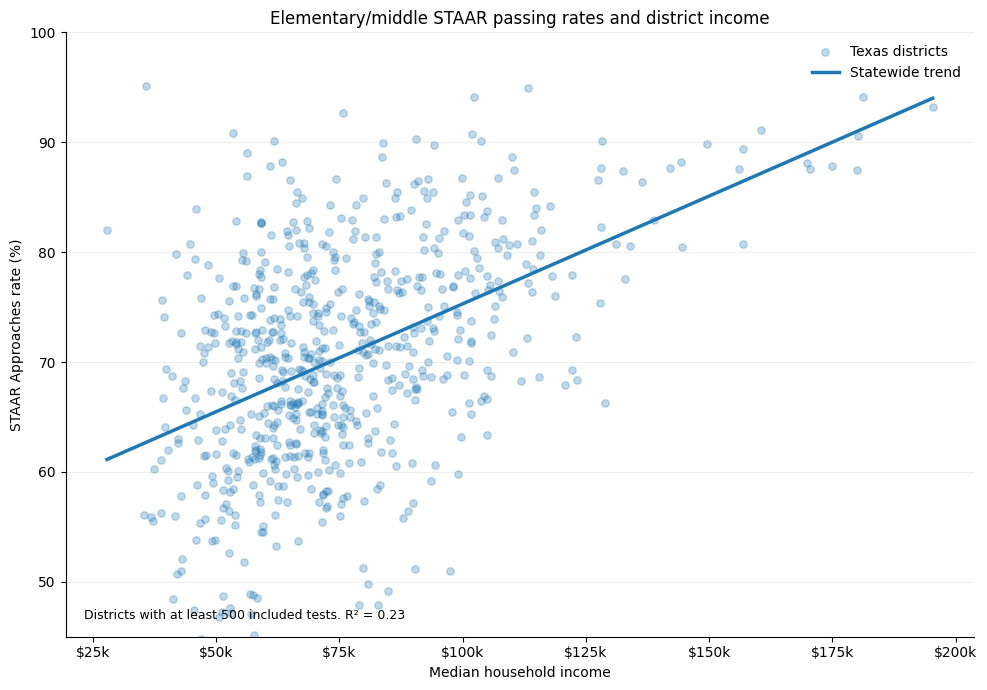

In [14]:
plot_regression(
    em_regression_data,
    em_regression,
    "Elementary/middle STAAR passing rates and district income",
)

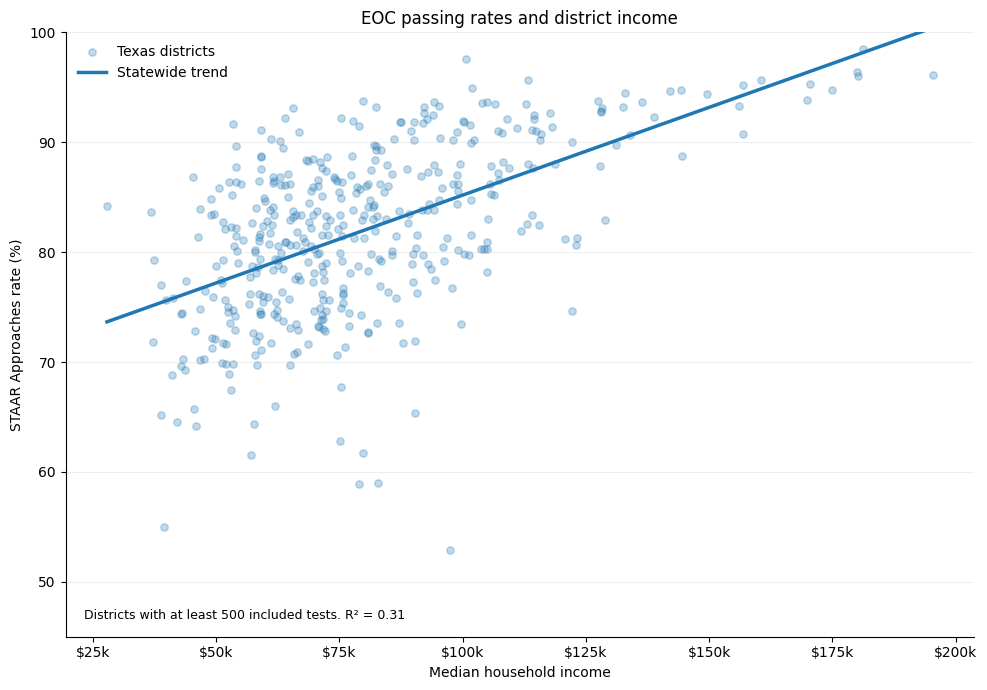

In [15]:
plot_regression(
    eoc_regression_data,
    eoc_regression,
    "EOC passing rates and district income",
)

## Classify statewide over- and under-performers

Open to changing these thresholds

- **Over expected:** residual of at least +5 percentage points
- **About expected:** residual between -5 and +5 percentage points
- **Under expected:** residual of at most -5 percentage points


In [16]:
def classify_performance(regression_data):
    output = regression_data.copy()

    output["performance_category"] = pd.cut(
        output["residual"],
        bins=[
            -float("inf"),
            -5,
            5,
            float("inf"),
        ],
        labels=[
            "Under expected",
            "About expected",
            "Over expected",
        ],
        include_lowest=True,
    )

    return (
        output
        .sort_values("residual", ascending=False)
        .reset_index(drop=True)
    )


em_results = classify_performance(em_regression_data)
eoc_results = classify_performance(eoc_regression_data)

In [17]:
display_columns = [
    "staar_district",
    "tea_district_id",
    "median_household_income",
    "income_moe",
    "approaches_pct",
    "predicted_approaches_pct",
    "residual",
    "tests_taken",
    "performance_category",
]

for label, dataframe in [
    ("Elementary/middle", em_results),
    ("EOC", eoc_results),
]:
    print(f"\n{label}: over expected")
    display(
        dataframe[
            dataframe["performance_category"] == "Over expected"
        ][display_columns]
    )

    print(f"\n{label}: about expected")
    display(
        dataframe[
            dataframe["performance_category"] == "About expected"
        ][display_columns]
    )

    print(f"\n{label}: under expected")
    display(
        dataframe[
            dataframe["performance_category"] == "Under expected"
        ][display_columns]
    )


Elementary/middle: over expected


,staar_district,tea_district_id,median_household_income,income_moe,approaches_pct,predicted_approaches_pct,residual,tests_taken,performance_category
0,MUMFORD ISD,198906,35724.0,18962.0,95.094340,62.675710,32.418630,530.0,Over expected
1,SANTA GERTRUDIS ISD,137904,53333.0,33960.0,90.814558,66.131938,24.682620,577.0,Over expected
2,CANADIAN ISD,106901,61648.0,22191.0,90.100671,67.763975,22.336696,596.0,Over expected
3,GEORGE WEST ISD,149901,56342.0,11929.0,89.019608,66.722534,22.297074,1020.0,Over expected
4,FLATONIA ISD,075901,75764.0,14291.0,92.631579,70.534611,22.096968,570.0,Over expected
...,...,...,...,...,...,...,...,...,...
185,COPPERAS COVE ISD,050910,73120.0,3572.0,75.253127,70.015657,5.237470,6716.0,Over expected
186,HICO ISD,097903,69640.0,6740.0,74.479167,69.332615,5.146551,576.0,Over expected
187,COLEMAN ISD,042901,47386.0,11931.0,70.029674,64.964683,5.064990,674.0,Over expected
188,ORANGEFIELD ISD,181905,84639.0,18127.0,77.341390,72.276563,5.064827,1655.0,Over expected



Elementary/middle: about expected


,staar_district,tea_district_id,median_household_income,income_moe,approaches_pct,predicted_approaches_pct,residual,tests_taken,performance_category
190,OLTON ISD,140905,61375.0,6010.0,72.710280,67.710392,4.999888,535.0,About expected
191,CLYDE CISD,030902,78981.0,11435.0,76.165414,71.166032,4.999382,1330.0,About expected
192,DIBOLL ISD,003905,61559.0,9202.0,72.740525,67.746507,4.994018,1372.0,About expected
193,HIDALGO ISD,108905,41094.0,17159.0,68.695321,63.729713,4.965608,2629.0,About expected
194,PERRYTON ISD,179901,70671.0,9400.0,74.430823,69.534976,4.895847,1713.0,About expected
...,...,...,...,...,...,...,...,...,...
472,LOCKHART ISD,028902,76224.0,5952.0,65.854047,70.624898,-4.770851,6276.0,About expected
473,FLORENCE ISD,246902,90000.0,13338.0,68.465116,73.328800,-4.863684,1075.0,About expected
474,CARROLLTON-FARMERS BRANCH ISD,057903,87139.0,2698.0,67.896569,72.767253,-4.870685,20110.0,About expected
475,PLEASANTON ISD,007905,66925.0,8049.0,63.904730,68.799725,-4.894995,2981.0,About expected



Elementary/middle: under expected


...

,staar_district,tea_district_id,median_household_income,income_moe,approaches_pct,predicted_approaches_pct,residual,tests_taken,performance_category
0,KEENE ISD,126906,53352.0,14140.0,91.633466,77.730525,13.902942,502,Over expected
1,CANTON ISD,234902,65671.0,11665.0,93.155452,79.698991,13.456461,862,Over expected
2,CARTHAGE ISD,183902,63860.0,13270.0,92.182410,79.409610,12.772801,921,Over expected
3,MINEOLA ISD,250903,59063.0,7325.0,91.079812,78.643092,12.436721,639,Over expected
4,FT SAM HOUSTON ISD,015914,100662.0,21360.0,97.570093,85.290242,12.279851,535,Over expected
...,...,...,...,...,...,...,...,...,...
92,ORANGEFIELD ISD,181905,84639.0,18127.0,87.961477,82.729909,5.231568,623,Over expected
93,WHITESBORO ISD,091909,81496.0,9392.0,87.443268,82.227686,5.215582,661,Over expected
94,LA GRANGE ISD,075902,75534.0,5301.0,86.397985,81.275011,5.122974,794,Over expected
95,DEVINE ISD,163901,61544.0,9548.0,84.063745,79.039533,5.024212,753,Over expected



EOC: about expected


,staar_district,tea_district_id,median_household_income,income_moe,approaches_pct,predicted_approaches_pct,residual,tests_taken,performance_category
97,LEVELLAND ISD,110902,60864.0,10723.0,83.870968,78.930875,4.940092,899,About expected
98,PARIS ISD,139909,46246.0,4128.0,81.395349,76.595049,4.800300,1247,About expected
99,CADDO MILLS ISD,116901,107083.0,13870.0,91.042345,86.316261,4.726084,1228,About expected
100,GRAPEVINE-COLLEYVILLE ISD,220906,117626.0,6703.0,92.680464,88.000939,4.679526,5943,About expected
101,CLEAR CREEK ISD,084910,102389.0,2875.0,90.222817,85.566201,4.656616,16426,About expected
...,...,...,...,...,...,...,...,...,...
328,TARKINGTON ISD,146907,99144.0,8518.0,80.195258,85.047679,-4.852421,717,About expected
329,TEXARKANA ISD,019907,49240.0,6030.0,72.205764,77.073464,-4.867700,3713,About expected
330,JASPER ISD,121904,53795.0,5442.0,72.919419,77.801312,-4.881893,757,About expected
331,MARBLE FALLS ISD,027904,75649.0,6586.0,76.320939,81.293387,-4.972448,1533,About expected



EOC: under expected


,staar_district,tea_district_id,median_household_income,income_moe,approaches_pct,predicted_approaches_pct,residual,tests_taken,performance_category
333,GEORGETOWN ISD,246904,104990.0,4395.0,80.946725,85.981818,-5.035093,5894,Under expected
334,NACOGDOCHES ISD,174904,49824.0,5221.0,72.098022,77.166782,-5.068759,2326,Under expected
335,AUSTIN ISD,227901,92946.0,1834.0,78.941216,84.057294,-5.116078,26521,Under expected
336,TEXAS CITY ISD,084906,62352.0,7643.0,74.052094,79.168645,-5.116551,3033,Under expected
337,COMMUNITY ISD,043918,111818.0,12450.0,81.901104,87.072872,-5.171768,2083,Under expected
...,...,...,...,...,...,...,...,...,...
424,DEL VALLE ISD,227910,79700.0,6324.0,61.743012,81.940701,-20.197688,5152,Under expected
425,LAREDO ISD,240901,39329.0,2198.0,54.946276,75.489774,-20.543497,2699,Under expected
426,FORT STOCKTON ISD,186902,79028.0,11019.0,58.932197,81.833321,-22.901125,4926,Under expected
427,HALLSVILLE ISD,102904,82924.0,11440.0,58.954791,82.455867,-23.501077,24110,Under expected


## San Antonio-area results

These tables use the separate elementary/middle and EOC regression lines.


In [18]:
sa_area_tea_ids = [
    "015901",  # Alamo Heights ISD
    "130901",  # Boerne ISD
    "046902",  # Comal ISD
    "015911",  # East Central ISD
    "015905",  # Edgewood ISD
    "015914",  # Ft Sam Houston ISD
    "015904",  # Harlandale ISD
    "015916",  # Judson ISD
    "015913",  # Lackland ISD
    "163908",  # Medina Valley ISD
    "015910",  # North East ISD
    "015915",  # Northside ISD
    "015906",  # Randolph Field ISD
    "015907",  # San Antonio ISD
    "094902",  # Schertz-Cibolo-U City ISD
    "015909",  # Somerset ISD
    "015908",  # South San Antonio ISD
    "015917",  # Southside ISD
    "015912",  # Southwest ISD
]

for label, dataframe in [
    ("Elementary/middle", em_results),
    ("EOC", eoc_results),
]:
    regional_results = dataframe[
        dataframe["tea_district_id"].isin(sa_area_tea_ids)
    ].copy()

    print(f"\n{label}: San Antonio-area districts")
    display(
        regional_results[
            display_columns
        ].sort_values("residual", ascending=False)
    )


Elementary/middle: San Antonio-area districts


,staar_district,tea_district_id,median_household_income,income_moe,approaches_pct,predicted_approaches_pct,residual,tests_taken,performance_category
13,RANDOLPH FIELD ISD,015906,113250.0,22031.0,94.951745,77.892223,17.059522,1347.0,Over expected
42,LACKLAND ISD,015913,64539.0,15330.0,81.530055,68.331410,13.198645,915.0,Over expected
98,FT SAM HOUSTON ISD,015914,100662.0,21360.0,84.543494,75.421497,9.121997,1391.0,Over expected
119,ALAMO HEIGHTS ISD,015901,100268.0,10037.0,83.379823,75.344164,8.035659,4302.0,Over expected
198,SOMERSET ISD,015909,72176.0,8968.0,74.567764,69.830372,4.737392,3586.0,About expected
220,BOERNE ISD,130901,136279.0,10659.0,86.420555,82.412269,4.008286,10781.0,About expected
242,COMAL ISD,046902,110926.0,3282.0,80.772826,77.436077,3.336750,28881.0,About expected
290,NORTH EAST ISD,015910,79074.0,1581.0,72.750991,71.184285,1.566706,48677.0,About expected
303,SOUTHSIDE ISD,015917,63269.0,6564.0,69.263158,68.082139,1.181019,5225.0,About expected
358,NORTHSIDE ISD,015915,80406.0,1191.0,70.672645,71.445725,-0.773081,86762.0,About expected



EOC: San Antonio-area districts


,staar_district,tea_district_id,median_household_income,income_moe,approaches_pct,predicted_approaches_pct,residual,tests_taken,performance_category
4,FT SAM HOUSTON ISD,015914,100662.0,21360.0,97.570093,85.290242,12.279851,535,Over expected
32,RANDOLPH FIELD ISD,015906,113250.0,22031.0,95.621716,87.301693,8.320024,571,Over expected
66,SOMERSET ISD,015909,72176.0,8968.0,87.395460,80.738432,6.657027,1674,Over expected
68,ALAMO HEIGHTS ISD,015901,100268.0,10037.0,91.815476,85.227284,6.588192,2016,Over expected
110,COMAL ISD,046902,110926.0,3282.0,91.252324,86.930338,4.321986,12369,About expected
121,NORTHSIDE ISD,015915,80406.0,1191.0,86.056272,82.053513,4.002758,40269,About expected
124,NORTH EAST ISD,015910,79074.0,1581.0,85.708025,81.840672,3.867353,22817,About expected
158,BOERNE ISD,130901,136279.0,10659.0,93.691275,90.981522,2.709753,4470,About expected
215,MEDINA VALLEY ISD,163908,99115.0,6604.0,85.575696,85.043045,0.532650,3917,About expected
255,SCHERTZ-CIBOLO-U CITY ISD,094902,105726.0,3973.0,85.269478,86.099424,-0.829947,7162,About expected


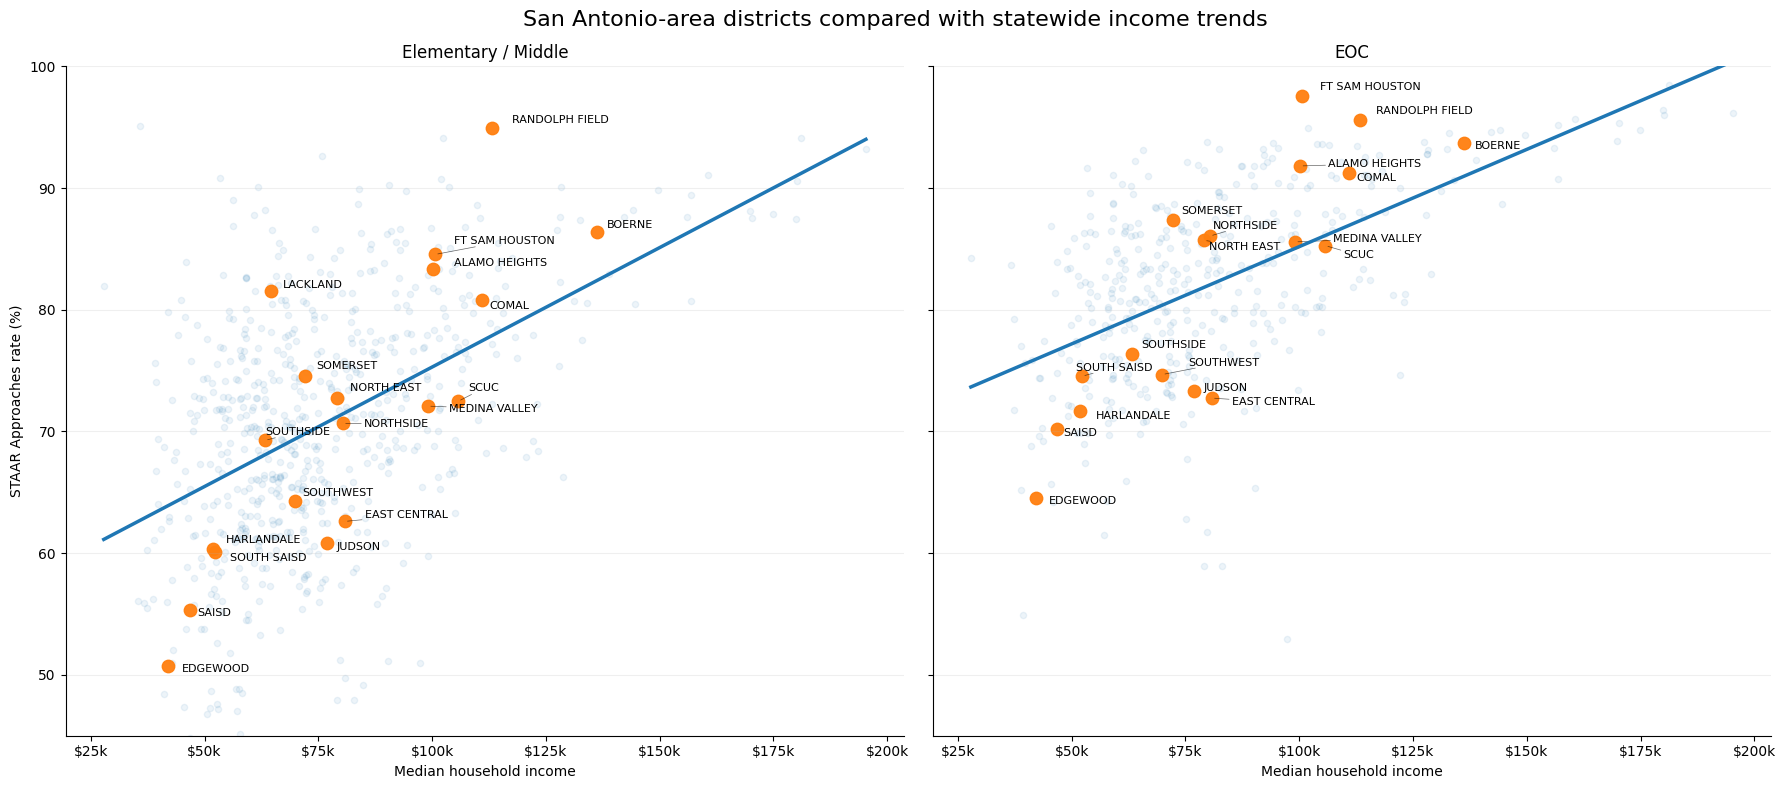

In [ ]:
## To make it easier, here it is visually

from adjustText import adjust_text
from matplotlib.ticker import FuncFormatter

sa_area_tea_ids = [
    "015901", "130901", "046902", "015911", "015905",
    "015914", "015904", "015916", "015913", "163908",
    "015910", "015915", "015906", "015907", "094902",
    "015909", "015908", "015917", "015912", # our usual list
]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 8),
    sharex=True,
    sharey=True,
)

plot_info = [
    (
        em_regression_data,
        em_regression,
        "Elementary / Middle",
    ),
    (
        eoc_regression_data,
        eoc_regression,
        "EOC",
    ),
]

for ax, (data, regression, title) in zip(axes, plot_info):

    data = data.copy()

    data["is_sa_area"] = (
        data["tea_district_id"].isin(sa_area_tea_ids)
    )

    sa_plot_data = data[data["is_sa_area"]].copy()

    x_line = np.linspace(
        data["median_household_income"].min(),
        data["median_household_income"].max(),
        100,
    )

    y_line = (
        regression.intercept
        + regression.slope * x_line
    )

    ax.scatter(
        data.loc[
            ~data["is_sa_area"],
            "median_household_income",
        ],
        data.loc[
            ~data["is_sa_area"],
            "approaches_pct",
        ],
        s=20,
        alpha=0.08,
    )

    ax.scatter(
        sa_plot_data["median_household_income"],
        sa_plot_data["approaches_pct"],
        s=80,
        alpha=0.95,
    )

    ax.plot(
        x_line,
        y_line,
        linewidth=2.5,
    )

    texts = []

    for _, row in sa_plot_data.iterrows():

        label = (
            row["staar_district"]
            .replace(" ISD", "")
            .replace("SCHERTZ-CIBOLO-U CITY", "SCUC")
            .replace("SAN ANTONIO", "SAISD")
            .replace("SOUTH SAN ANTONIO", "South San")
        )

        texts.append(
            ax.text(
                row["median_household_income"],
                row["approaches_pct"],
                label,
                fontsize=8,
            )
        )

    adjust_text(
        texts,
        ax=ax,
        arrowprops=dict(
            arrowstyle="-",
            lw=0.5,
            alpha=0.6,
        ),
    )

    ax.set_title(title)

    ax.xaxis.set_major_formatter(
        FuncFormatter(
            lambda x, pos: f"${x/1000:.0f}k"
        )
    )

    ax.set_ylim(45, 100)

    ax.grid(
        axis="y",
        alpha=0.2,
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel(
    "STAAR Approaches rate (%)"
)

for ax in axes:
    ax.set_xlabel(
        "Median household income"
    )

fig.suptitle(
    "San Antonio-area districts compared with statewide income trends",
    fontsize=16,
)

plt.tight_layout()

plt.show()

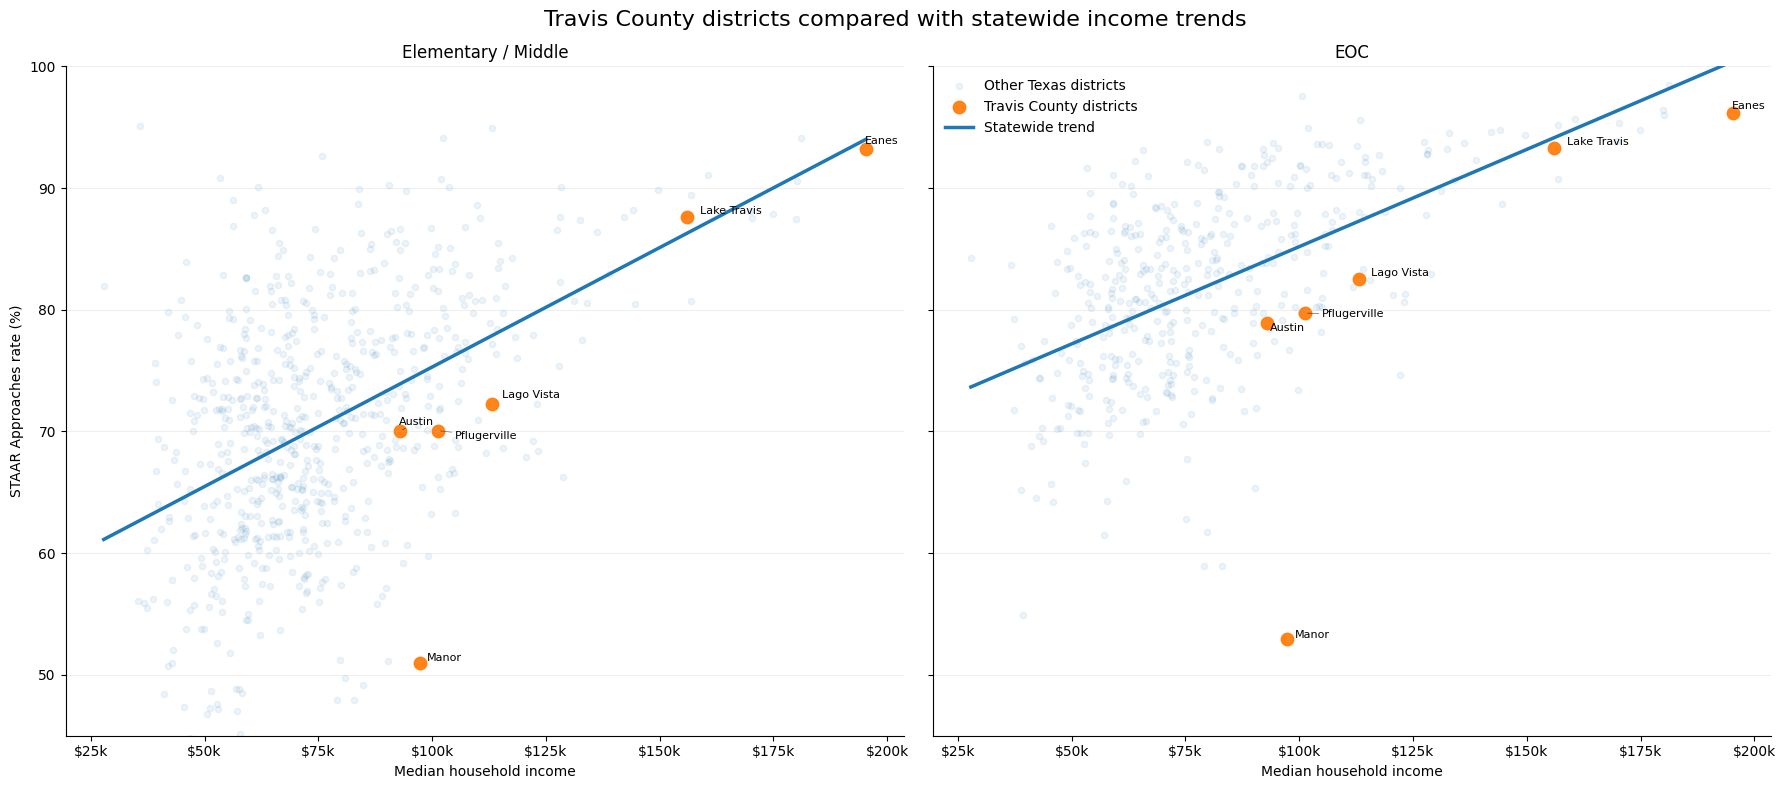

In [21]:
## Travis-area districts, elementary/middle vs. EOC

from adjustText import adjust_text
from matplotlib.ticker import FuncFormatter

travis_area_tea_ids = [
    "227901",  # Austin ISD
    "227904",  # Pflugerville ISD
    "227907",  # Manor ISD
    "227909",  # Eanes ISD
    "227912",  # Lago Vista ISD
    "227913",  # Lake Travis ISD
]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 8),
    sharex=True,
    sharey=True,
)

plot_info = [
    (
        em_regression_data,
        em_regression,
        "Elementary / Middle",
    ),
    (
        eoc_regression_data,
        eoc_regression,
        "EOC",
    ),
]

for ax, (data, regression, title) in zip(axes, plot_info):

    data = data.copy()

    data["is_travis_area"] = (
        data["tea_district_id"].isin(travis_area_tea_ids)
    )

    travis_plot_data = data[
        data["is_travis_area"]
    ].copy()

    x_line = np.linspace(
        data["median_household_income"].min(),
        data["median_household_income"].max(),
        100,
    )

    y_line = (
        regression.intercept
        + regression.slope * x_line
    )

    # All other Texas districts.
    ax.scatter(
        data.loc[
            ~data["is_travis_area"],
            "median_household_income",
        ],
        data.loc[
            ~data["is_travis_area"],
            "approaches_pct",
        ],
        s=20,
        alpha=0.08,
        label="Other Texas districts",
    )

    # Travis County districts.
    ax.scatter(
        travis_plot_data["median_household_income"],
        travis_plot_data["approaches_pct"],
        s=80,
        alpha=0.95,
        label="Travis County districts",
    )

    ax.plot(
        x_line,
        y_line,
        linewidth=2.5,
        label="Statewide trend",
    )

    texts = []

    for _, row in travis_plot_data.iterrows():

        label = (
            row["staar_district"]
            .replace(" ISD", "")
            .replace("AUSTIN", "Austin")
            .replace("PFLUGERVILLE", "Pflugerville")
            .replace("MANOR", "Manor")
            .replace("EANES", "Eanes")
            .replace("LAGO VISTA", "Lago Vista")
            .replace("LAKE TRAVIS", "Lake Travis")
        )

        texts.append(
            ax.text(
                row["median_household_income"],
                row["approaches_pct"],
                label,
                fontsize=8,
            )
        )

    adjust_text(
        texts,
        ax=ax,
        arrowprops=dict(
            arrowstyle="-",
            lw=0.5,
            alpha=0.6,
        ),
    )

    ax.set_title(title)

    ax.xaxis.set_major_formatter(
        FuncFormatter(
            lambda x, pos: f"${x / 1000:.0f}k"
        )
    )

    ax.set_ylim(45, 100)
    ax.grid(axis="y", alpha=0.2)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("STAAR Approaches rate (%)")

for ax in axes:
    ax.set_xlabel("Median household income")

axes[1].legend(frameon=False)

fig.suptitle(
    "Travis County districts compared with statewide income trends",
    fontsize=16,
)

plt.tight_layout()
plt.show()

## Export regression results

Both exports include the income estimate, actual Approaches rate, fitted value, residual and performance category.


In [19]:
em_results.to_csv(
    EM_OUTPUT_FILE,
    index=False,
)

eoc_results.to_csv(
    EOC_OUTPUT_FILE,
    index=False,
)

regression_comparison.to_csv(
    REGRESSION_SUMMARY_FILE,
    index=False,
)

print(f"Saved {len(em_results):,} elementary/middle districts to:")
print(EM_OUTPUT_FILE)

print(f"\nSaved {len(eoc_results):,} EOC districts to:")
print(EOC_OUTPUT_FILE)

print("\nSaved model comparison to:")
print(REGRESSION_SUMMARY_FILE)

Saved 674 elementary/middle districts to:
../data/processed/district_income_staar_elementary_middle_regression.csv

Saved 429 EOC districts to:
../data/processed/district_income_staar_eoc_regression.csv

Saved model comparison to:
../data/processed/separate_staar_regression_summary.csv
